In [1]:
# uvoz potrebnih biblioteka i definisanje osnovnih parametara

import random
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import permutations
import math

N_PRISONERS = 100
N_BOXES = 100
MAX_ATTEMPTS = 50

In [2]:
# 1. Nasumicna strategija
random.seed(42)
np.random.seed(42)

N_SIMULATIONS_RANDOM = 100_000

def generate_boxes(n = 100):
    boxes = list(range(1, n + 1))
    random.shuffle(boxes)
    return boxes

def random_strategy_success(boxes, prisoner, max_attempts = 50):
    chosen_boxes = random.sample(range(1, len(boxes) + 1), max_attempts)

    for box in chosen_boxes:
        if boxes[box - 1] == prisoner: # lista se indeksira od nule, pa je kutija k u nasoj listi indeksirana sa k - 1
            return True

    return False

def all_prisoners_random(boxes, max_attempts = 50):
    n = len(boxes)

    for prisoner in range(1, n + 1):

        success = random_strategy_success(
            boxes,
            prisoner,
            max_attempts
        )

        if not success:
            return False

    return True

success_count = 0

for _ in range(N_SIMULATIONS_RANDOM):

    boxes = generate_boxes()

    if all_prisoners_random(boxes):
        success_count += 1


# Rezultati

estimated_probability = success_count / N_SIMULATIONS_RANDOM

print("BROJ SIMULACIJA:", N_SIMULATIONS_RANDOM)
print("BROJ USPEHA:", success_count)
print("PROCENJENA VEROVATNOĆA USPEHA:", estimated_probability)

BROJ SIMULACIJA: 100000
BROJ USPEHA: 0
PROCENJENA VEROVATNOĆA USPEHA: 0.0


In [3]:
# eksperimentalno poredjenje nekoliko strategija, od kojih je jedna "loop" strategija, tj. strategija pracenja ciklusa
random.seed(42)
np.random.seed(42)

N_SIMULATIONS = 100_000
N = 100
MAX_ATTEMPTS = 50

def generate_boxes(n = N):

    boxes = list(range(1, n + 1))
    random.shuffle(boxes)
    return boxes


# 1. NASUMICNA STRATEGIJA
def random_strategy(boxes, prisoner, max_attempts = MAX_ATTEMPTS):
    chosen_boxes = random.sample(range(1, len(boxes) + 1), max_attempts)

    for box in chosen_boxes:
        if boxes[box - 1] == prisoner:
            return True

    return False


# 2. STRATEGIJA REDOM
# zatvorenik i otvara kutije i, i + 1, i + 2, ...
# ciklicno se vraca na pocetak ako predje broj 100
def sequential_strategy(boxes, prisoner, max_attempts=MAX_ATTEMPTS):
    n = len(boxes)

    for step in range(max_attempts):
        box = ((prisoner - 1 + step) % n) + 1

        if boxes[box - 1] == prisoner:
            return True

    return False


# 3. BLOK STRATEGIJA
# naivna ali organizovana strategija u kojoj zatvorenici 1-50 otvaraju prvi blok kutija
# a zatvorenici 51-100 drugi blok kutija
def block_strategy(boxes, prisoner, max_attempts=MAX_ATTEMPTS):

    if prisoner <= 50:
        chosen_boxes = range(1, 51)
    else:
        chosen_boxes = range(51, 101)

    for box in chosen_boxes:
        if boxes[box - 1] == prisoner:
            return True

    return False


# 4. LOOP STRATEGIJA
def loop_strategy(boxes, prisoner, max_attempts=MAX_ATTEMPTS):
    current_box = prisoner

    for _ in range(max_attempts):
        number_inside = boxes[current_box - 1]

        if number_inside == prisoner:
            return True

        current_box = number_inside

    return False

def all_prisoners_success(boxes, strategy_function, max_attempts=MAX_ATTEMPTS):
    n = len(boxes)

    for prisoner in range(1, n + 1):
        if not strategy_function(boxes, prisoner, max_attempts):
            return False

    return True


strategies = {
    "Random strategija": random_strategy,
    "Strategija redom": sequential_strategy,
    "Blok strategija": block_strategy,
    "Loop strategija": loop_strategy
}


results = []

# eksperiment uspesnosti strategija
for strategy_name, strategy_function in strategies.items():
    success_count = 0

    for _ in range(N_SIMULATIONS):
        boxes = generate_boxes(N)

        if all_prisoners_success(boxes, strategy_function, MAX_ATTEMPTS):
            success_count += 1

    estimated_probability = success_count / N_SIMULATIONS

    results.append({
        "Strategija": strategy_name,
        "Broj uspeha": success_count,
        "Broj simulacija": N_SIMULATIONS,
        "Procenjena verovatnoća": estimated_probability
    })


results_df = pd.DataFrame(results)
results_df = results_df.sort_values(
    by="Procenjena verovatnoća",
    ascending=False
).reset_index(drop=True)

best_strategy = results_df.iloc[0]

print("REZULTATI POREĐENJA STRATEGIJA")
display(results_df)

print("\nNajbolja strategija je:")
print(best_strategy["Strategija"])
print("Procenjena verovatnoća uspeha:", best_strategy["Procenjena verovatnoća"])

REZULTATI POREĐENJA STRATEGIJA


,Strategija,Broj uspeha,Broj simulacija,Procenjena verovatnoća
0,Loop strategija,31195,100000,0.31195
1,Random strategija,0,100000,0.00000
2,Strategija redom,0,100000,0.00000
3,Blok strategija,0,100000,0.00000



Najbolja strategija je:
Loop strategija
Procenjena verovatnoća uspeha: 0.31195


In [4]:
# eksperimentalna pretraga bolje strategije od nasumicnih za n = 6 i poredjenje sa loop strategijom
random.seed(42)
np.random.seed(42)

N_SMALL = 6
MAX_ATTEMPTS_SMALL = 3
N_RANDOM_STRATEGIES = 10_000

# Sve moguće permutacije kutija
ALL_PERMUTATIONS = list(
    permutations(range(1, N_SMALL + 1))
)

TOTAL_PERMUTATIONS = len(ALL_PERMUTATIONS)

print("Ukupan broj permutacija:", TOTAL_PERMUTATIONS)

def loop_strategy_small(boxes, prisoner):

    current_box = prisoner

    for _ in range(MAX_ATTEMPTS_SMALL):

        number_inside = boxes[current_box - 1]

        if number_inside == prisoner:
            return True

        current_box = number_inside

    return False

def generate_random_strategy():

    strategy = {}

    for current_box in range(1, N_SMALL + 1):

        strategy[current_box] = {}

        for number_seen in range(1, N_SMALL + 1):

            next_box = random.randint(1, N_SMALL)

            strategy[current_box][number_seen] = next_box

    return strategy


def random_generated_strategy_success(boxes, prisoner, strategy):

    current_box = prisoner

    visited_boxes = set()

    for _ in range(MAX_ATTEMPTS_SMALL):

        if current_box in visited_boxes:
            break

        visited_boxes.add(current_box)

        number_inside = boxes[current_box - 1]

        if number_inside == prisoner:
            return True

        current_box = strategy[current_box][number_inside]

    return False


def all_prisoners_success_loop(boxes):

    for prisoner in range(1, N_SMALL + 1):

        if not loop_strategy_small(boxes, prisoner):
            return False

    return True


def all_prisoners_success_random_strategy(boxes, strategy):

    for prisoner in range(1, N_SMALL + 1):

        if not random_generated_strategy_success(boxes, prisoner, strategy):
            return False

    return True

loop_successes = 0

for perm in ALL_PERMUTATIONS:

    boxes = list(perm)

    if all_prisoners_success_loop(boxes):
        loop_successes += 1

loop_probability = loop_successes / TOTAL_PERMUTATIONS

print("\nLOOP STRATEGIJA")
print("Broj uspešnih rasporeda:", loop_successes)
print("Tačna verovatnoća:", loop_probability)

# testiranje velikog broja nasumicnih strategija
best_random_probability = 0
best_random_strategy_index = None

results = []

for strategy_index in range(N_RANDOM_STRATEGIES):

    strategy = generate_random_strategy()

    success_count = 0

    for perm in ALL_PERMUTATIONS:

        boxes = list(perm)

        if all_prisoners_success_random_strategy(
            boxes,
            strategy
        ):
            success_count += 1

    probability = success_count / TOTAL_PERMUTATIONS

    results.append(probability)

    if probability > best_random_probability:

        best_random_probability = probability
        best_random_strategy_index = strategy_index
        

#rezultati
results_df = pd.DataFrame({
    "Strategija": [
        "Loop strategija",
        "Najbolja pronađena random strategija"
    ],
    "Verovatnoća uspeha": [
        loop_probability,
        best_random_probability
    ]
})

display(results_df)

print("\nNajbolja random strategija:")
print(best_random_probability)

print("\nLoop strategija:")
print(loop_probability)

if loop_probability > best_random_probability:

    print("\nLoop strategija je bolja od svih generisanih strategija.")
else:

    print("\nPronađena je strategija bolja od loop strategije.")

Ukupan broj permutacija: 720

LOOP STRATEGIJA
Broj uspešnih rasporeda: 276
Tačna verovatnoća: 0.38333333333333336


,Strategija,Verovatnoća uspeha
0,Loop strategija,0.383333
1,Najbolja pronađena random strategija,0.023611



Najbolja random strategija:
0.02361111111111111

Loop strategija:
0.38333333333333336

Loop strategija je bolja od svih generisanih strategija.


In [5]:
# eksperimentalna pretraga bolje strategije od zadatih slozenijih za n = 6 i poredjenje sa loop strategijom
random.seed(42)
np.random.seed(42)

N_SMALL = 6
MAX_ATTEMPTS_SMALL = 3
N_SMART_STRATEGIES = 10000

ALL_PERMUTATIONS = list(permutations(range(1, N_SMALL + 1)))
TOTAL_PERMUTATIONS = len(ALL_PERMUTATIONS)

print("Broj zatvorenika:", N_SMALL)
print("Maksimalan broj otvaranja:", MAX_ATTEMPTS_SMALL)
print("Broj svih permutacija:", TOTAL_PERMUTATIONS)
print("Broj generisanih pametnijih strategija:", N_SMART_STRATEGIES)


def loop_strategy_success(boxes, prisoner, max_attempts=MAX_ATTEMPTS_SMALL):
    current_box = prisoner

    for _ in range(max_attempts):
        number_inside = boxes[current_box - 1]

        if number_inside == prisoner:
            return True

        current_box = number_inside

    return False


def all_success_loop(boxes):
    for prisoner in range(1, N_SMALL + 1):
        if not loop_strategy_success(boxes, prisoner):
            return False
    return True


# generisanje slozenijih strategija
def generate_smart_strategy(n=N_SMALL):
    
    strategy_type = random.choice([
        "shifted_loop",
        "partial_loop",
        "affine_rule",
        "avoid_seen",
        "mixed"
    ])

    shift = random.randint(1, n - 1)
    multiplier = random.randint(1, n)
    bias = random.randint(0, n - 1)
    loop_probability = random.uniform(0.3, 0.95)
    avoid_seen = random.choice([True, False])

    return {
        "type": strategy_type,
        "shift": shift,
        "multiplier": multiplier,
        "bias": bias,
        "loop_probability": loop_probability,
        "avoid_seen": avoid_seen
    }

# na osnovu izvucenog broja i izabrane strategije bira se sledeca kutija na zadat nacin
def choose_next_box(number_inside, current_box, prisoner, seen_boxes, strategy, n=N_SMALL):
   
    strategy_type = strategy["type"]

    # 1. Pomerena loop strategija:
    # umesto da ide tačno na kutiju number_inside, ide na kutiju number_inside + shift
    if strategy_type == "shifted_loop":
        next_box = ((number_inside - 1 + strategy["shift"]) % n) + 1

    # 2. Delimična loop strategija:
    # sa nekom verovatnoćom prati loop, a inače bira pomereno
    elif strategy_type == "partial_loop":
        if random.random() < strategy["loop_probability"]:
            next_box = number_inside
        else:
            next_box = ((number_inside - 1 + strategy["shift"]) % n) + 1

    # 3. Afirmno pravilo:
    # sledeća kutija je određena formulom a * broj + b, moduo n
    elif strategy_type == "affine_rule":
        next_box = ((strategy["multiplier"] * number_inside + strategy["bias"] - 1) % n) + 1

    # 4. Izbegavanje već viđenih kutija:
    # polazi od loop izbora, ali ako je kutija već viđena, bira najbližu sledeću neviđenu
    elif strategy_type == "avoid_seen":
        next_box = number_inside

        if next_box in seen_boxes:
            candidates = [box for box in range(1, n + 1) if box not in seen_boxes]
            if candidates:
                next_box = min(candidates, key=lambda x: abs(x - number_inside))

    # 5. Mešovita strategija:
    # kombinuje loop, pomeraj i afino pravilo
    else:
        choice = random.choice(["loop", "shift", "affine"])

        if choice == "loop":
            next_box = number_inside
        elif choice == "shift":
            next_box = ((number_inside - 1 + strategy["shift"]) % n) + 1
        else:
            next_box = ((strategy["multiplier"] * number_inside + strategy["bias"] - 1) % n) + 1

    # Ako strategija traži izbegavanje viđenih kutija, pokušavamo da ne ponavljamo kutiju
    if strategy["avoid_seen"] and next_box in seen_boxes:
        candidates = [box for box in range(1, n + 1) if box not in seen_boxes]

        if candidates:
            next_box = random.choice(candidates)

    return next_box


def smart_strategy_success(boxes, prisoner, strategy, max_attempts=MAX_ATTEMPTS_SMALL):
    
    current_box = prisoner
    seen_boxes = set()

    for _ in range(max_attempts):

        if current_box in seen_boxes:
            return False

        seen_boxes.add(current_box)

        number_inside = boxes[current_box - 1]

        if number_inside == prisoner:
            return True

        current_box = choose_next_box(
            number_inside=number_inside,
            current_box=current_box,
            prisoner=prisoner,
            seen_boxes=seen_boxes,
            strategy=strategy
        )

    return False


def all_success_smart_strategy(boxes, strategy):
    for prisoner in range(1, N_SMALL + 1):
        if not smart_strategy_success(boxes, prisoner, strategy):
            return False
    return True


loop_success_count = 0

for perm in ALL_PERMUTATIONS:
    boxes = list(perm)

    if all_success_loop(boxes):
        loop_success_count += 1

loop_probability = loop_success_count / TOTAL_PERMUTATIONS

print("\nLOOP STRATEGIJA")
print("Broj uspešnih rasporeda:", loop_success_count)
print("Tačna verovatnoća uspeha:", loop_probability)


# testiranje 10 000 slozenjih strategija
smart_results = []

best_probability = 0
best_strategy = None

for strategy_id in range(1, N_SMART_STRATEGIES + 1):

    strategy = generate_smart_strategy(N_SMALL)

    success_count = 0

    for perm in ALL_PERMUTATIONS:
        boxes = list(perm)

        if all_success_smart_strategy(boxes, strategy):
            success_count += 1

    probability = success_count / TOTAL_PERMUTATIONS

    # preskačemo strategije koje daju isti rezultat kao loop strategija, 
    # jer tada znamo da smo zapravo dobili loop strategiju samo indirektno definisanu 
    if probability == loop_probability:
        continue

    smart_results.append({
        "ID strategije": strategy_id,
        "Tip strategije": strategy["type"],
        "Verovatnoća uspeha": probability,
        "Shift": strategy["shift"],
        "Multiplier": strategy["multiplier"],
        "Bias": strategy["bias"],
        "Loop probability": strategy["loop_probability"],
        "Avoid seen": strategy["avoid_seen"]
    })

    if probability > best_probability:
        best_probability = probability
        best_strategy = strategy


smart_results_df = pd.DataFrame(smart_results)

top_10 = smart_results_df.sort_values(
    by="Verovatnoća uspeha",
    ascending=False
).head(10)

print("\nTOP 10 pronađenih sofisticiranijih strategija:")
display(top_10)

comparison_df = pd.DataFrame({
    "Strategija": [
        "Loop strategija",
        "Najbolja sofisticiranija generisana strategija"
    ],
    "Verovatnoća uspeha": [
        loop_probability,
        best_probability
    ]
})

print("\nPOREĐENJE SA LOOP STRATEGIJOM:")
display(comparison_df)

print("\nNajbolja pronađena sofisticiranija strategija:")
print(best_strategy)

if loop_probability >= best_probability:
    print("\nZaključak: Ni jedna od generisanih sofisticiranijih strategija nije pobedila loop strategiju.")
else:
    print("\nZaključak: Pronađena je strategija koja je bolja od loop strategije u ovom eksperimentu.")

Broj zatvorenika: 6
Maksimalan broj otvaranja: 3
Broj svih permutacija: 720
Broj generisanih pametnijih strategija: 10000

LOOP STRATEGIJA
Broj uspešnih rasporeda: 276
Tačna verovatnoća uspeha: 0.38333333333333336

TOP 10 pronađenih sofisticiranijih strategija:


,ID strategije,Tip strategije,Verovatnoća uspeha,Shift,Multiplier,Bias,Loop probability,Avoid seen
7693,9683,partial_loop,0.294444,3,5,0,0.948513,True
2615,3286,partial_loop,0.294444,1,3,0,0.949944,True
2556,3219,partial_loop,0.288889,2,5,3,0.941619,True
4839,6061,partial_loop,0.288889,5,3,0,0.939235,True
5133,6455,partial_loop,0.288889,2,6,1,0.947592,True
965,1195,partial_loop,0.286111,4,4,3,0.945484,True
1444,1794,partial_loop,0.284722,2,4,5,0.943055,True
3370,4229,partial_loop,0.281944,1,4,5,0.947591,True
7460,9386,partial_loop,0.279167,2,2,4,0.943563,False
3543,4432,partial_loop,0.279167,3,5,0,0.938389,True



POREĐENJE SA LOOP STRATEGIJOM:


,Strategija,Verovatnoća uspeha
0,Loop strategija,0.383333
1,Najbolja sofisticiranija generisana strategija,0.294444



Najbolja pronađena sofisticiranija strategija:
{'type': 'partial_loop', 'shift': 1, 'multiplier': 3, 'bias': 0, 'loop_probability': 0.9499439264818459, 'avoid_seen': True}

Zaključak: Ni jedna od generisanih sofisticiranijih strategija nije pobedila loop strategiju.


Broj simulacija: 100000
Procenjena verovatnoća uspeha: 0.31099
Procenjena verovatnoća neuspeha: 0.68901


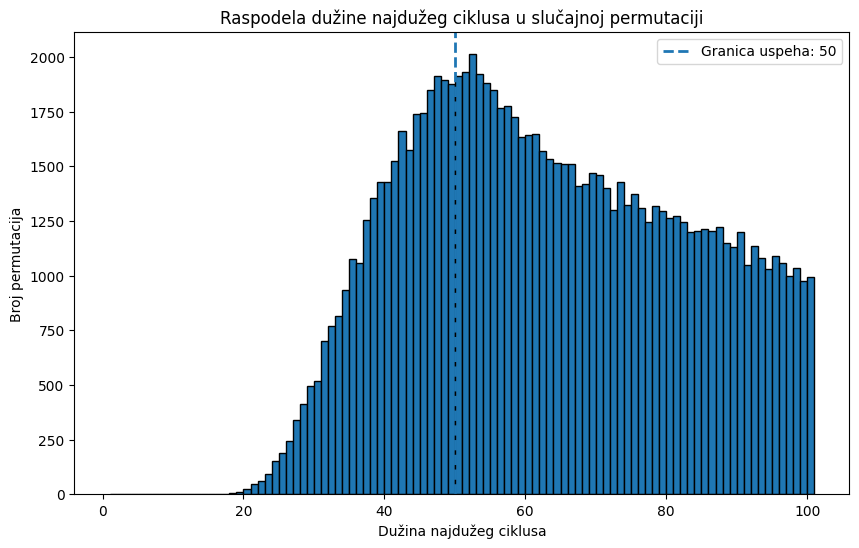

In [6]:
# histogram najduzeg ciklusa u slucajnoj permutacji 
random.seed(42)
np.random.seed(42)

N = 100
MAX_ATTEMPTS = 50
N_SIMULATIONS = 100_000


def generate_boxes(n=N):
    boxes = list(range(1, n + 1))
    random.shuffle(boxes)
    return boxes


def cycle_lengths(boxes):

    n = len(boxes)
    visited = [False] * n
    lengths = []

    for start in range(1, n + 1):
        if not visited[start - 1]:

            current = start
            length = 0

            while not visited[current - 1]:
                visited[current - 1] = True
                length += 1
                current = boxes[current - 1]

            lengths.append(length)

    return lengths


longest_cycles = []

for _ in range(N_SIMULATIONS):
    boxes = generate_boxes(N)
    lengths = cycle_lengths(boxes)
    longest_cycles.append(max(lengths))


longest_cycles_df = pd.DataFrame({
    "Najduži ciklus": longest_cycles
})

success_rate = (longest_cycles_df["Najduži ciklus"] <= MAX_ATTEMPTS).mean()
failure_rate = 1 - success_rate

print("Broj simulacija:", N_SIMULATIONS)
print("Procenjena verovatnoća uspeha:", success_rate)
print("Procenjena verovatnoća neuspeha:", failure_rate)


plt.figure(figsize=(10, 6))

plt.hist(
    longest_cycles,
    bins=range(1, N + 2),
    edgecolor="black"
)

plt.axvline(
    MAX_ATTEMPTS,
    linestyle="--",
    linewidth=2,
    label="Granica uspeha: 50"
)

plt.xlabel("Dužina najdužeg ciklusa")
plt.ylabel("Broj permutacija")
plt.title("Raspodela dužine najdužeg ciklusa u slučajnoj permutaciji")

plt.legend()
plt.show()

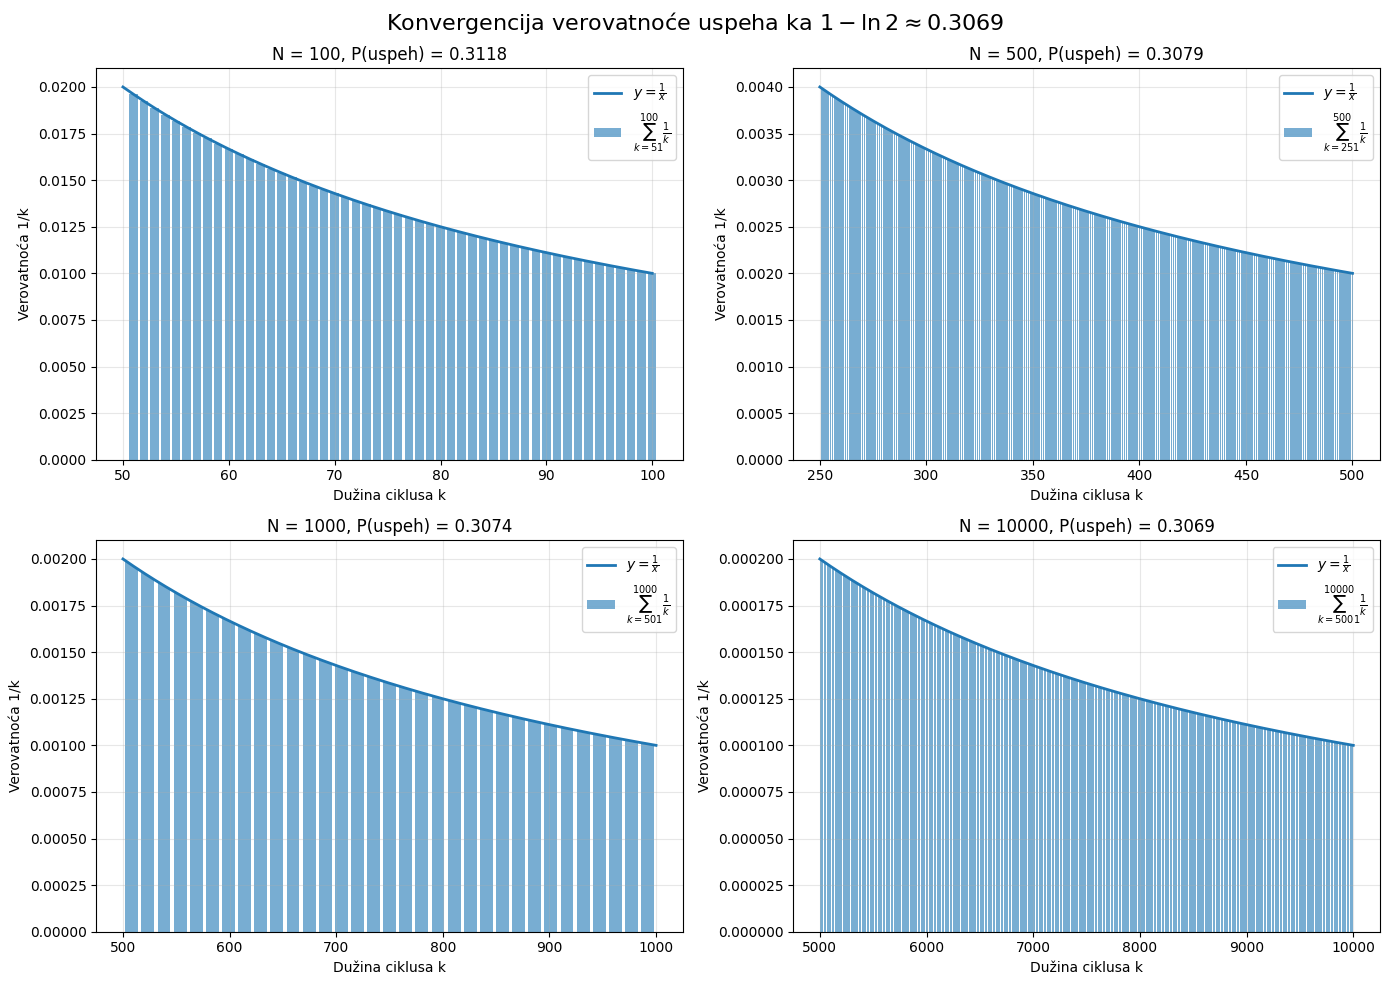

In [7]:
# empirijska konvergencija ka 1 - ln(2)
random.seed(42)
np.random.seed(42)

N_values = [100, 500, 1000, 10_000]
limit_value = 1 - math.log(2)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, N in zip(axes.ravel(), N_values):
    
    half = N // 2
    k_values = np.arange(half + 1, N + 1)
    probabilities = 1 / k_values

    failure_probability = probabilities.sum()
    success_probability = 1 - failure_probability

    x_curve = np.linspace(half, N, 500)
    y_curve = 1 / x_curve

    ax.bar(
        k_values,
        probabilities,
        alpha=0.6,
        label=fr"$\sum_{{k={half+1}}}^{{{N}}} \frac{{1}}{{k}}$"
    )

    ax.plot(
        x_curve,
        y_curve,
        linewidth=2,
        label=r"$y=\frac{1}{x}$"
    )

    ax.set_title(
        f"N = {N}, P(uspeh) = {success_probability:.4f}"
    )

    ax.set_xlabel("Dužina ciklusa k")
    ax.set_ylabel("Verovatnoća 1/k")
    ax.legend()
    ax.grid(True, alpha=0.3)

fig.suptitle(
    fr"Konvergencija verovatnoće uspeha ka $1-\ln 2 \approx {limit_value:.4f}$",
    fontsize=16
)

plt.tight_layout()
plt.show()